# Setup

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from gpcam import GPOptimizer
import time
from itertools import product
latent_x = np.linspace(0,1,1000).reshape(-1,1)
latent_x.shape

(1000, 1)

# gpOptimizer: Mini Application

## Data Preparation
* GP inputs `x` are usually 2D: shape `(n_samples, n_features)` (so 1D feature still looks like `(n,1)`).
* Target/label arrays `y` are often expected as 1D: shape `(n,)`.
* `flatten()` is used to convert `(n,1)` or similar into `(n,)` when a metric/function expects 1D vectors.


So: keep `x` as 2D for model methods, and flatten outputs/targets when functions (like metrics) require 1D.

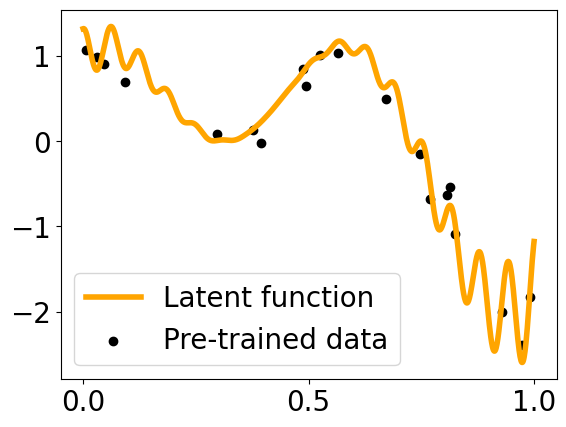

In [2]:
def f1(x):  # the latent function is the underlying function that we want to predict
    return np.sin(5. * x) + np.cos(10. * x) + (2.* (x-0.4)**2) * np.cos(100. * x)

seed = 99
np.random.seed(seed)
x_data = np.random.rand(20).reshape(-1,1) 
y_data = f1(x_data[:,0]) + (np.random.rand(len(x_data))-0.5) * 0.5  # the observed data which is the latent function plus some noise

plt.figure()    # figsize = (15,5)
plt.xticks([0.,0.5,1.0])
plt.yticks([-2,-1,0.,1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.plot(latent_x, f1(latent_x), color = 'orange', linewidth = 4, label='Latent function')
plt.scatter(x_data[:,0], y_data, color = 'black', label='Pre-trained data')
plt.legend(fontsize=20, loc='lower left')
plt.show()

## GP Setup

In [3]:
my_gp = GPOptimizer(x_data, y_data) # Feed the observed data to the GP
my_gp.train()
NUMBER_TRAINING = 100
train_at = [10,20,30] #optional
# Training the GP
new_x_bound = np.array([[0.,1.]])
print(f'GP returning keys: {my_gp.ask(new_x_bound).keys()}')
for i in range(NUMBER_TRAINING):
    new_return_dict = my_gp.ask(new_x_bound)
    new = new_return_dict["x"]
    predicted_value = new_return_dict["f_a(x)"]
    if i%10 == 0:
        print(f'Iteration {i:2d}: New point to be evaluated: {new}; Predicted value: {predicted_value}; True value: {f1(new).reshape(len(new))}')
    my_gp.tell(new, (f1(new)+ (np.random.rand(len(new))-0.5) * 0.5).reshape(len(new)))
    if i in train_at:  # train the GP after a certain number of iterations
        print(f'Training the GP at iteration {i} {new_return_dict}')
        my_gp.train()

c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\fvgp\gp.py:248: UserWarning: Hyperparameters initialized to a vector of ones.
  warnings.warn("Hyperparameters initialized to a vector of ones.")
c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\fvgp\gp.py:292: UserWarning: No noise function or measurement noise provided. Noise variances will be set to (0.01 * mean(|y_data|))^2.
  self.likelihood = GPlikelihood(self.data,
c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\fvgp\gp.py:523: UserWarning: Default hyperparameter_bounds initialized because none were provided. This will fail for custom kernel, mean, or noise functions
  warnings.warn("Default hyperparameter_bounds initialized because none were provided. "


GP returning keys: dict_keys(['x', 'f_a(x)', 'opt_obj'])
Iteration  0: New point to be evaluated: [[0.19634953]]; Predicted value: [0.93063802]; True value: [0.50743873]
Iteration 10: New point to be evaluated: [[0.22186537]]; Predicted value: [0.35563752]; True value: [0.22966353]
Training the GP at iteration 10 {'x': array([[0.22186537]]), 'f_a(x)': array([0.35563752]), 'opt_obj': None}
Iteration 20: New point to be evaluated: [[0.35631391]]; Predicted value: [0.23431554]; True value: [0.06359252]
Training the GP at iteration 20 {'x': array([[0.35631391]]), 'f_a(x)': array([0.23431554]), 'opt_obj': None}
Iteration 30: New point to be evaluated: [[0.83995776]]; Predicted value: [0.17194595]; True value: [-1.65245311]
Training the GP at iteration 30 {'x': array([[0.83995776]]), 'f_a(x)': array([0.17194595]), 'opt_obj': None}
Iteration 40: New point to be evaluated: [[0.86624803]]; Predicted value: [0.12940358]; True value: [-1.55194485]
Iteration 50: New point to be evaluated: [[0.9624

## Make prediction

{'x': array([[0.]]), 'm(x)': array([1.45589113]), 'm(x)_flat': array([1.45589113]), 'x_pred': array([[0.]])}
{'x': array([[0.]]), 'x_pred': array([[0.]]), 'v(x)': array([0.00014277]), 'S': array([[0.00014277]]), 'S_flat': array([[0.00014277]]), 'v_flat': array([0.00014277])}


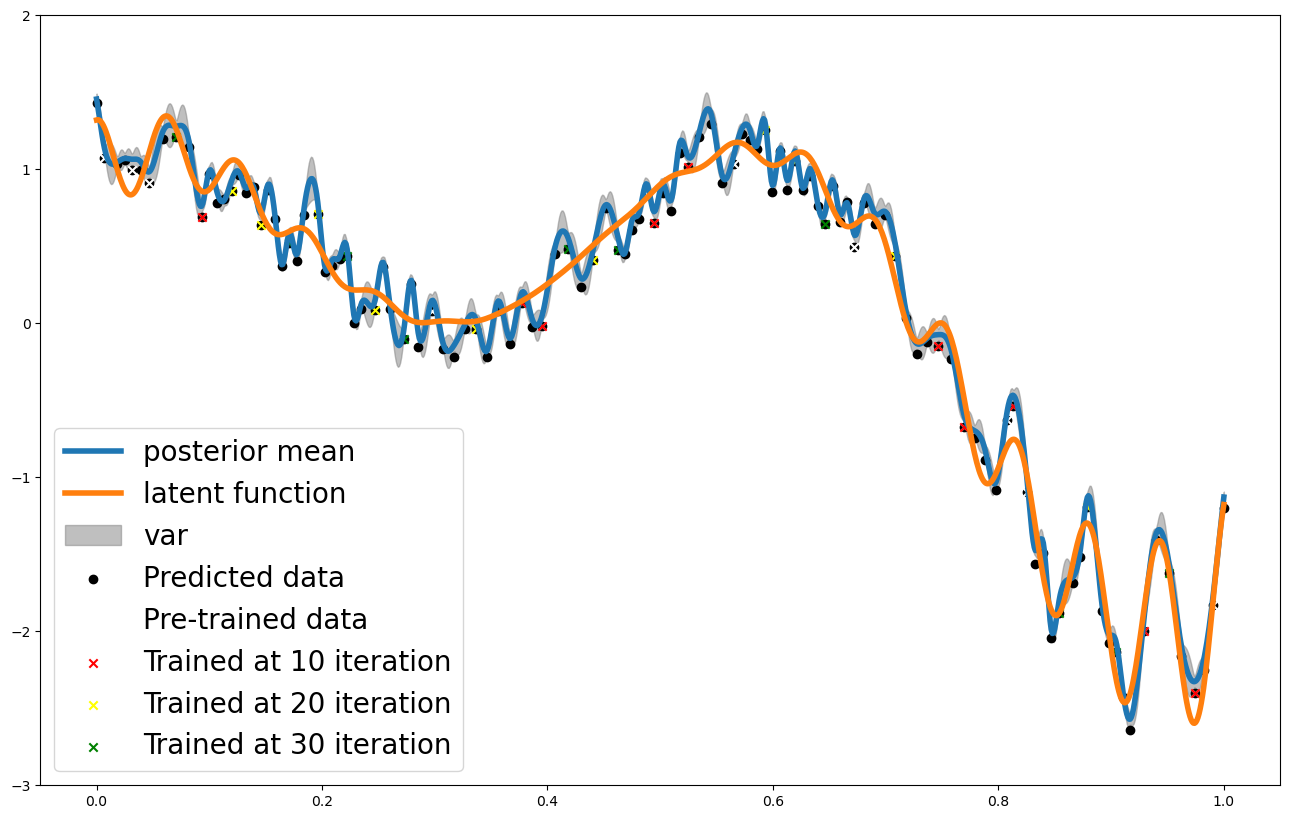

Number of training data: 120
0.14085384999795744
(np.float64(0.10638322826160121), np.float64(0.07610700730686268))


In [6]:
# x_pred = np.linspace(0, 1, 1000)
# print(f'x_pred: {x_pred[:5]}; x_pred1D: {x_pred1D[:5]}')

print(my_gp.posterior_mean(latent_x[:1]))
mean1 = my_gp.posterior_mean(latent_x)["m(x)"]
print(my_gp.posterior_covariance(latent_x[:1], variance_only=False, add_noise=True))
var1 =  my_gp.posterior_covariance(latent_x, variance_only=False, add_noise=True)["v(x)"]

plt.figure(figsize = (16,10))    # figsize = (16,10)

plt.plot(latent_x, mean1, label = "posterior mean", linewidth = 4)
plt.plot(latent_x, f1(latent_x), label = "latent function", linewidth = 4)
plt.fill_between(latent_x[:, 0], mean1 - 3. * np.sqrt(var1), mean1 + 3. * np.sqrt(var1), alpha = 0.5, color = "grey", label = "var")
plt.scatter(my_gp.x_data, my_gp.y_data, color = 'black', label='Predicted data') # my_gp.x_data, my_gp.y_data means the initial training data plus the new training data
# Pre-trained data
plt.scatter(x_data[:,0], y_data, color = 'white', label='Pre-trained data', marker='x')
# Trained at 10 iteration
plt.scatter(my_gp.x_data[10:20,0], my_gp.y_data[10:20], color = 'red', label='Trained at 10 iteration', marker='x')
# Trained at 20 iteration
plt.scatter(my_gp.x_data[20:30,0], my_gp.y_data[20:30], color = 'yellow', label='Trained at 20 iteration', marker='x')
# Trained at 30 iteration
plt.scatter(my_gp.x_data[30:40,0], my_gp.y_data[30:40], color = 'green', label='Trained at 30 iteration', marker='x')
plt.ylim(-3,2)
plt.legend(fontsize=20, loc='lower left')
plt.show()

print(f'Number of training data: {len(my_gp.x_data)}')

##looking at some validation metrics
print(my_gp.rmse(latent_x, f1(latent_x).flatten()))
print(my_gp.crps(latent_x, f1(latent_x).flatten()))

# gpOptimizer: Single-Task Acquisition Function

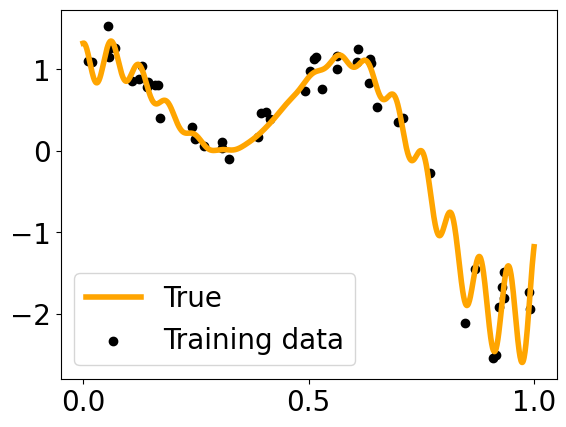

In [ ]:
def f1(x):
    return np.sin(5. * x) + np.cos(10. * x) + (2.* (x-0.4)**2) * np.cos(100. * x)
 
x_data = np.random.rand(50).reshape(-1,1) 
y_data = f1(x_data[:,0]) + (np.random.rand(len(x_data))-0.5) * 0.5

plt.figure()    # figsize = (15,5)
plt.xticks([0.,0.5,1.0])
plt.yticks([-2,-1,0.,1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.plot(latent_x, f1(latent_x), color = 'orange', linewidth = 4, label='True')
plt.scatter(x_data[:,0], y_data, color = 'black', label='Training data')
plt.legend(fontsize=20, loc='lower left')
plt.show()

## Customizing the Guassian Process

The kernel is the model of how function values relate. skernel is your custom covariance function; it encodes assumptions like smoothness and length scale. That determines:

* How strongly points influence each other (correlation vs distance).
* Smoothness/roughness of sampled functions.
* The shape of uncertainty and interpolation between data.
* How the GP generalizes in regions with no data.

Why use a prior mean in a GP:

* Encode known trends or baselines so the GP doesn’t have to “waste” kernel capacity modeling them.
* Improve extrapolation. Far from data, the GP reverts to the prior mean; a good mean gives a sane default.
* Reduce bias from zero-mean default when you know the function isn’t centered at zero.
* Help with data-sparse regions and faster convergence during hyperparameter fitting.

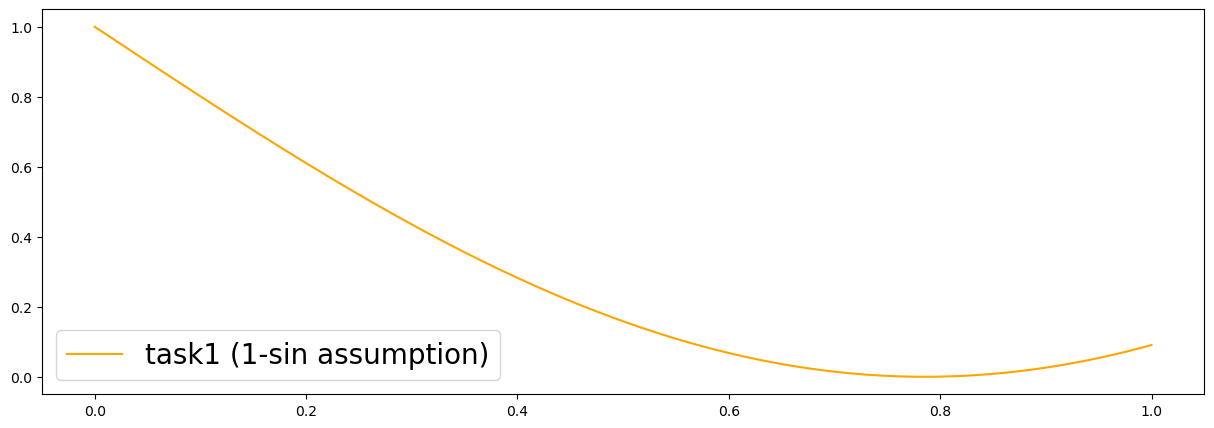

In [8]:
def my_noise(x,hps):
    #This is a simple noise function but can be made arbitrarily complex using many hyperparameters.
    #The noise function can return a matrix or a vector 
    return np.zeros((len(x))) + hps[2]

#stationary
from gpcam.kernels import *
def skernel(x1,x2,hps):
    #The kernel follows the mathematical definition of a kernel. This
    #means there is no limit to the variety of kernels you can define.
    d = get_distance_matrix(x1, x2)
    return hps[0] * matern_kernel_diff1(d, hps[1])


def meanf(x, hps):
    #This is a simple mean function but it can be arbitrarily complex using many hyperparameters.
    return 1.-np.sin(hps[3] * x[:,0])

#it is a good idea to plot the prior mean function to make sure we did not mess up
plt.figure(figsize = (15,5))
plt.plot(latent_x, meanf(latent_x, np.array([1., 1., 5., 2.])), color = 'orange', label = 'task1 (1-sin assumption)')
plt.legend(fontsize=20, loc='lower left')
plt.show()

## Initialize and Different Training options

In [ ]:
my_gpo = GPOptimizer(x_data,y_data,
            init_hyperparameters = np.ones((4))/10.,  # We need enough of those for kernel, noise, and prior mean functions 
            compute_device='cpu', 
            kernel_function=skernel, 
            kernel_function_grad=None, 
            prior_mean_function=meanf, 
            prior_mean_function_grad=None,
            noise_function=my_noise,
            #noise_variances=np.zeros(y_data.shape) + 0.1,
            gp2Scale = False,
            calc_inv=False, 
            ram_economy=False, 
            args={'a': 1.5, 'b':2.},
            )   

hps_bounds = np.array([[0.01,10.],     # signal variance for the kernel
                       [0.01,10.],     # length scale for the kernel
                       [0.00001,0.1],  # noise
                       [0.00001,1.]    # mean
                      ])

my_gpo.tell(x_data, y_data, append=True) # Append the existing data
# my_gpo.tell(x_data, y_data, append=False) # Overwrite the existing data

st = time.time()
print("Standard Training (MCMC)")
hps = my_gpo.train(hyperparameter_bounds=hps_bounds, info = True, max_iter = 100)
print("Final hyperparammeters =", hps, "after ", time.time() - st, " seconds")
print("")

# print("Global Training")
# my_gpo.train(hyperparameter_bounds=hps_bounds, method='global', max_iter = 20)
# print("Final hyperparammeters =", hps, "after ", time.time() - st, " seconds")
# print("")

# print("Local Training")
# my_gpo.train(hyperparameter_bounds=hps_bounds, method='local')
# print("Final hyperparammeters =", hps, "after ", time.time() - st, " seconds")
# print("")

# from distributed import Client
# client = Client()
# print("HGDL Training")
# my_gpo.train(hyperparameter_bounds=hps_bounds, method='hgdl', max_iter=2, dask_client=client)
# print("Final hyperparammeters =", hps, "after ", time.time() - st, " seconds")
# print("")

Standard Training (MCMC)
Finished  10  out of  100  MCMC iterations. f(x)=  -52.76473527518879
Finished  20  out of  100  MCMC iterations. f(x)=  -52.76473527518879
Finished  30  out of  100  MCMC iterations. f(x)=  -14.526274337202885
Finished  40  out of  100  MCMC iterations. f(x)=  -15.966444476212509
Finished  50  out of  100  MCMC iterations. f(x)=  -14.143719045207181
Finished  60  out of  100  MCMC iterations. f(x)=  -10.942852702036227
Finished  70  out of  100  MCMC iterations. f(x)=  -10.926477322162597
Finished  80  out of  100  MCMC iterations. f(x)=  -11.363903597780038
Finished  90  out of  100  MCMC iterations. f(x)=  -12.666179469388332
Final hyperparammeter = [2.5014491  0.29954353 0.08860659 0.03385331] after  0.01713085174560547  seconds



## Vizualizing the Results

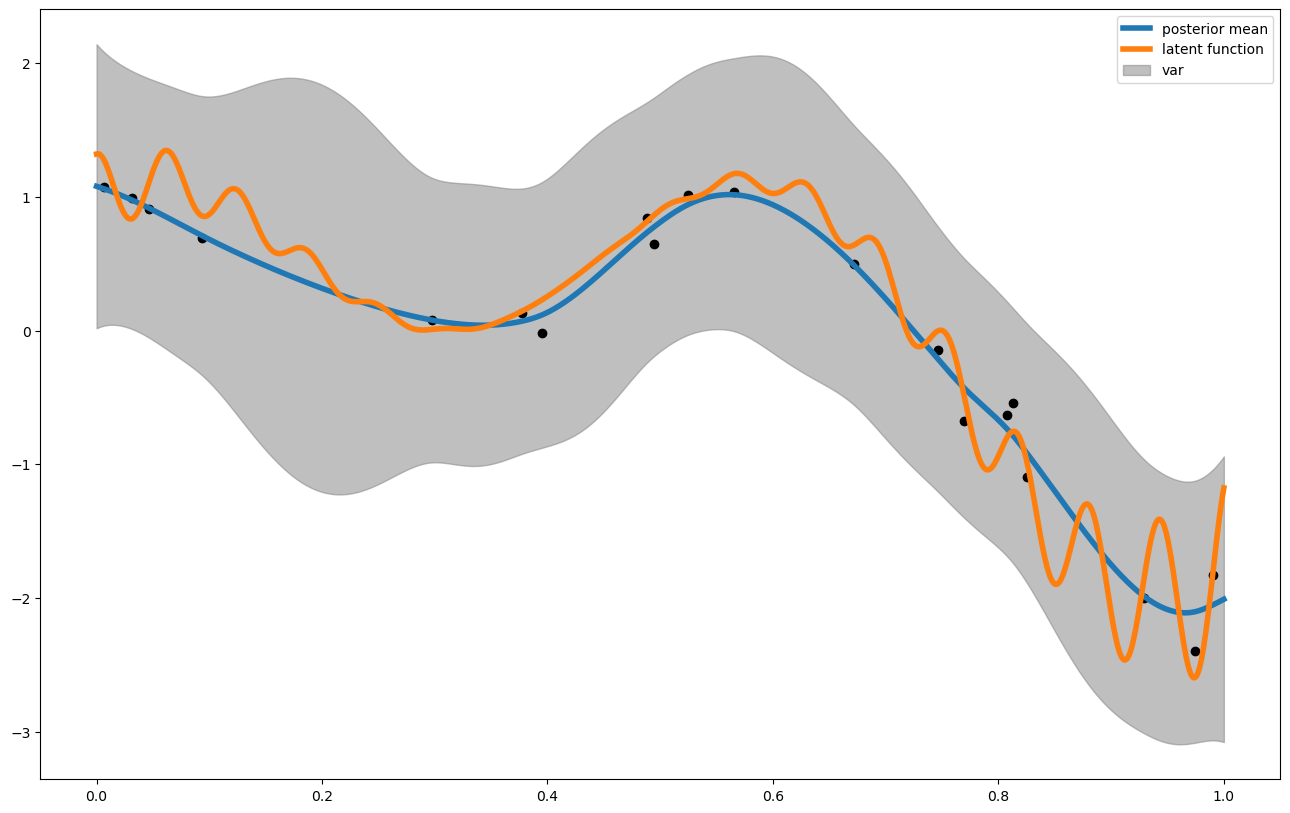

0.2476254545143657
(np.float64(0.1413393116459545), np.float64(0.12953832870431634))


2026-02-12 09:51:56,015 - distributed.nanny - ERROR - 
Traceback (most recent call last):
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\distributed\utils.py", line 832, in wrapper
    return await func(*args, **kwargs)
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\distributed\nanny.py", line 555, in _on_worker_exit
    await self._unregister()
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\distributed\nanny.py", line 305, in _unregister
    await wait_for(
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\distributed\utils.py", line 1940, in wait_for
    return await asyncio.wait_for(fut, timeout)
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\asyncio\tasks.py", line 451, in wait_for
    await _cancel_and_wait(fut, loop=loop)
  File "c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\asyncio\tasks.py", line 518, in _cancel_and_wait
    await waiter
asyncio.exceptions.CancelledError
2026-02-12 09:

In [24]:
mean1 = my_gpo.posterior_mean(latent_x)["m(x)"]
var1 =  my_gpo.posterior_covariance(latent_x, variance_only=False, add_noise=True)["v(x)"]

plt.figure(figsize = (16,10))
plt.plot(latent_x, mean1, label = "posterior mean", linewidth = 4)
plt.plot(latent_x, f1(latent_x), label = "latent function", linewidth = 4)
plt.fill_between(latent_x[:, 0], mean1 - 3. * np.sqrt(var1), mean1 + 3. * np.sqrt(var1), alpha = 0.5, color = "grey", label = "var")
plt.scatter(x_data, y_data, color = 'black')
# plt.scatter(my_gpo.x_data, my_gpo.y_data, color = 'red')
plt.legend()
plt.show()


##looking at some validation metrics
print(my_gpo.rmse(latent_x,f1(latent_x).flatten()))
print(my_gpo.crps(latent_x,f1(latent_x).flatten()))

## Acquisition functions
* variance: simply the posterior variance;
* relative information entropy: the KL (Kullback–Leibler divergence) divergence of the prior over predictions and the posterior;
* relative information entropy set: the KL (Kullback–Leibler divergence) divergence of the prior over predictions and the posterior point-by-point;
* ucb: upper confidence bound, posterior mean + 3. std;
* lcb: lower confidence bound, -(posterior mean - 3. std);
* maximum: finds the maximum of the current posterior mean;
* minimum: finds the maximum of the current posterior mean;
* gradient: puts focus on high-gradient regions;
* probability of improvement: as the name would suggest;
* expected improvement: as the name would suggest;
* total correlation: extension of mutual information to more than 2 random variables;
* target probability: probability of a target. This needs a dictionary args = {‘a’: lower bound, ‘b’: upper bound} to be defined.

Acquisition function  variance
Acquisition function  relative information entropy
Some acquisition function return a scalar score for the entirety of points. Here:  relative information entropy
Acquisition function  relative information entropy set
Acquisition function  ucb
Acquisition function  lcb
Acquisition function  maximum
Acquisition function  minimum
Acquisition function  gradient
Acquisition function  expected improvement
Acquisition function  probability of improvement
Acquisition function  target probability
Acquisition function  total correlation
Some acquisition function return a scalar score for the entirety of points. Here:  total correlation


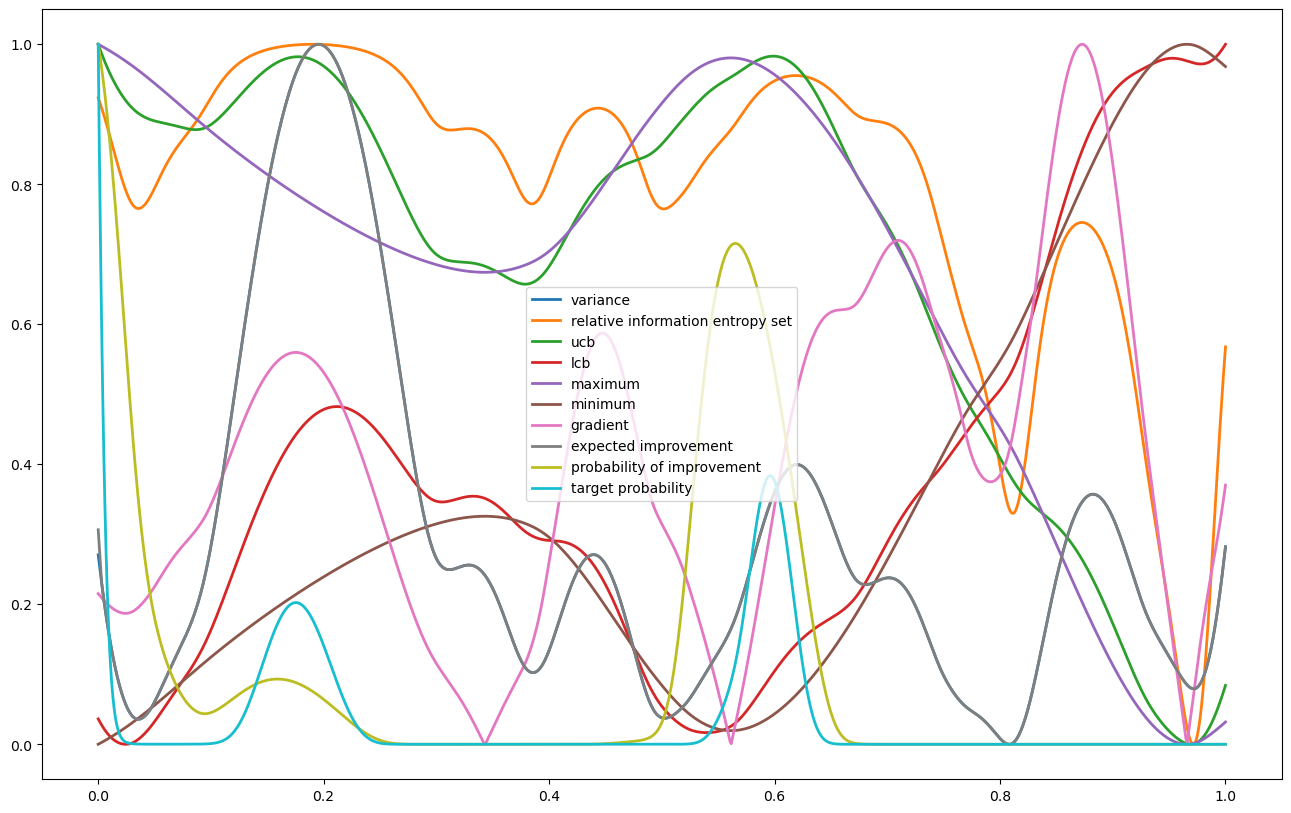

In [ ]:
acquisition_functions = ["variance","relative information entropy","relative information entropy set",
                        "ucb","lcb","maximum","minimum","gradient","expected improvement",
                         "probability of improvement", "target probability", "total correlation"]

plt.figure(figsize=(16,10))
for acq_func in acquisition_functions:
    print("Acquisition function ", acq_func)
    res = my_gpo.evaluate_acquisition_function(latent_x, acquisition_function=acq_func)
    if len(res)==len(latent_x):
        res = res - np.min(res)
        res = res/np.max(res)
        plt.plot(latent_x, res, label = acq_func, linewidth = 2)
    else: print("Some acquisition function return a scalar score for the entirety of points. Here: ", acq_func)
plt.legend()
plt.show()

## Optimal Evaluations
with several optimization methods and acquisition functions

c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58307 instead
  warnings.warn(
c:\CCC\Software\Anaconda\envs\BNL310PtyINR\lib\contextlib.py:142: UserWarning: Creating scratch directories is taking a surprisingly long time. (2.18s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Acquisition function  ucb  and method  global
led to new suggestion: 
 {'x': array([[0.59571708]]), 'f_a(x)': array([1.59556363]), 'opt_obj': None}

Acquisition function  ucb  and method  local
led to new suggestion: 
 {'x': array([[0.]]), 'f_a(x)': array([1.65360714]), 'opt_obj': None}

Acquisition function  ucb  and method  hgdl
[[0.]
 [0.]
 [0.]] [0]
led to new suggestion: 
 {'x': array([[0.]]), 'f_a(x)': array([1.65360714]), 'opt_obj': <hgdl.hgdl.HGDL object at 0x0000016057313C40>}

Acquisition function  variance  and method  global
led to new suggestion: 
 {'x': array([[0.17745471]]), 'f_a(x)': array([0.40168841]), 'opt_obj': None}

Acquisition function  variance  and method  local
led to new suggestion: 
 {'x': array([[1.]]), 'f_a(x)': array([0.19514856]), 'opt_obj': None}

Acquisition function  variance  and method  hgdl
[[0.]
 [0.]
 [0.]] [0]
led to new suggestion: 
 {'x': array([[0.]]), 'f_a(x)': array([1.65360714]), 'opt_obj': <hgdl.hgdl.HGDL object at 0x0000016057343F10>}



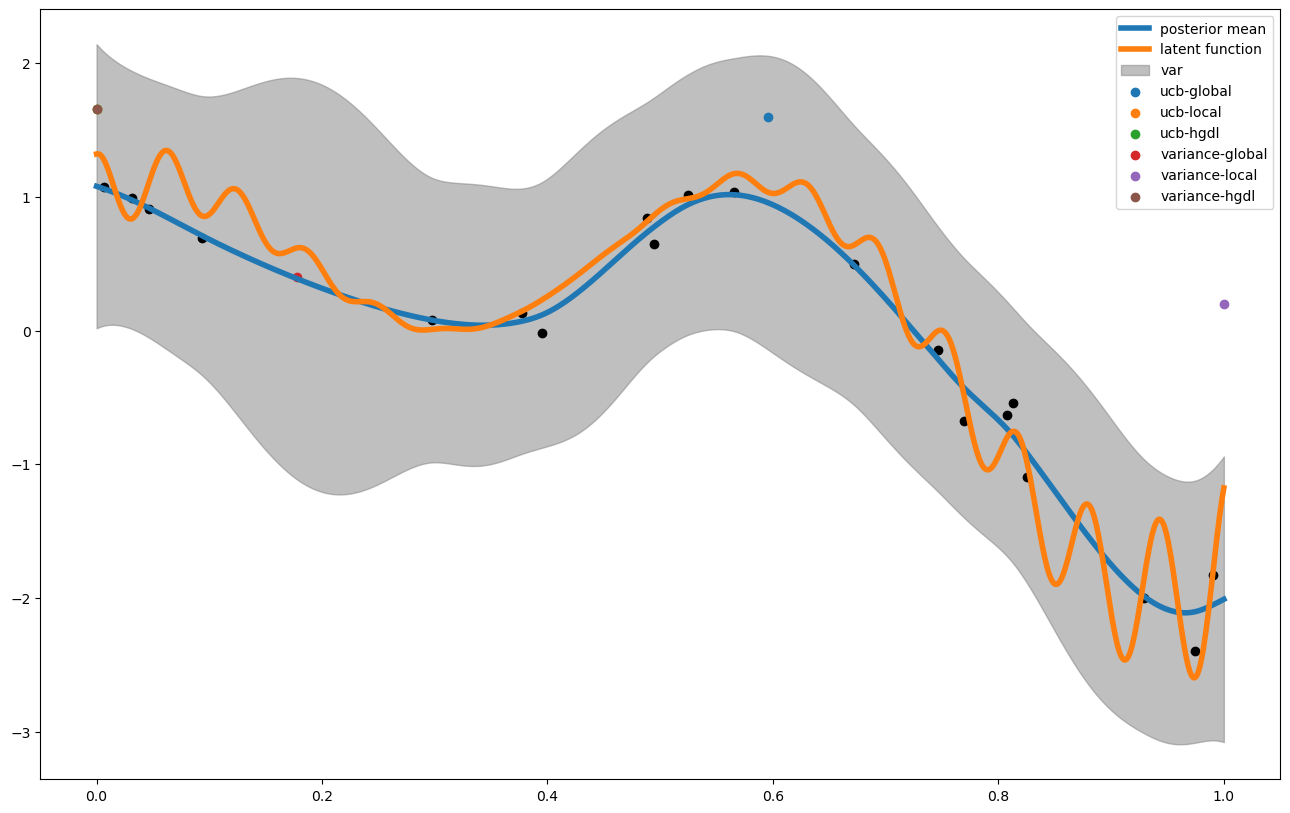

In [22]:
from distributed import Client
client = Client()

plt.figure(figsize = (16,10))
plt.plot(latent_x, mean1, label = "posterior mean", linewidth = 4)
plt.plot(latent_x, f1(latent_x), label = "latent function", linewidth = 4)
plt.fill_between(latent_x[:, 0], mean1 - 3. * np.sqrt(var1), mean1 + 3. * np.sqrt(var1), alpha = 0.5, color = "grey", label = "var")
plt.scatter(x_data, y_data, color = 'black')


#let's test the asks:
bounds = np.array([[0.0,1.0]])
for acq_func in ['ucb', 'variance']: #acquisition_functions:
    for method in ["global", "local", "hgdl"]:
        print("Acquisition function ", acq_func," and method ",method)
        new_suggestion = my_gpo.ask(bounds, acquisition_function=acq_func, 
                                    method=method, max_iter = 2, dask_client=client)
        print("led to new suggestion: \n", new_suggestion)
        x = new_suggestion['x']
        y = new_suggestion['f_a(x)']
        plt.scatter(x, y, label=f'{acq_func}-{method}')
        print("")

plt.legend()
plt.show()

# GP simulation

## Results exploration

In [1]:
import xml.etree.ElementTree as ET

xml_path = r"/Users/carlyzincone/Desktop/RESEARCH/Local Computer Beamline Data/cms data/20250623_CMS_SSMD/CrCuNiCr-CuVTiCu-AE/analysis_smaxs/results/b65-04-CrCuNiCr_Tc80.35_4232.3s_x24.822_th0.200_10.00s_2049261_maxs.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

# Extract all <result> elements with name/value/error
for result in root.iter('result'):
    name = result.get('name')
    value = result.get('value')
    error = result.get('error')
    print(f"{name}: value={value}, error={error}")


qn_power: value=2.0, error=None
fit_peaks_m: value=-167.07339617910338, error=63.64297749144109
fit_peaks_b: value=1017.090594529861, error=192.9422750552341
fit_peaks_qp: value=0, error=0
fit_peaks_qalpha: value=1.0, error=0
fit_peaks_prefactor1: value=1888.3355817940505, error=28.352410756258553
fit_peaks_x_center1: value=3.07202326386817, error=0.000767469386621867
fit_peaks_sigma1: value=0.04510653819129475, error=0.0008550050821139819
fit_peaks_prefactor_total: value=1888.3355817940505, error=None
fit_peaks_chi_squared: value=6020.273430710485, error=None
fit_peaks_d01: value=0.20452922284410202, error=5.1096591307957676e-05
fit_peaks_grain_size1: value=5.557128467719038, error=0.10533668227230625
fit_peaks_d0: value=0.20452922284410202, error=5.1096591307957676e-05
fit_peaks_grain_size: value=5.557128467719038, error=0.10533668227230625
infile: value=../maxs/raw/b65-04-CrCuNiCr_Tc80.35_4232.3s_x24.822_th0.200_10.00s_2049261_maxs.tiff, error=None
filepath: value=../maxs/raw, error

## Get a single value

In [2]:
for result in root.iter('result'):
    if result.get('name') == 'fit_peaks_sigma1':
        print(f"Value: {result.get('value')}")  # 3.505172467615249
        print(f"Error: {result.get('error')}")  # 0.00017372187578368987

Value: 0.04510653819129475
Error: 0.0008550050821139819


## Single dataset

In [3]:
import pandas as pd
from pathlib import Path

FILE_PATH = Path(r"/Users/carlyzincone/Desktop/RESEARCH/Local Computer Beamline Data/cms data/20250623_CMS_SSMD/CrCuNiCr-CuVTiCu-AE/analysis_smaxs/results")
xml_files = list(FILE_PATH.glob("b65-04-CrCuNiCr_T*_maxs*.xml"))
FEATURE1 = 'fit_peaks_sigma1'

rows = []
for f in xml_files:
    tree = ET.parse(f)
    row = {'file': f}
    print(f.stem)
    for result in tree.getroot().iter('result'):
        if result.get('name') == FEATURE1:
            value = round(float(result.get('value')), 5)
            error = round(float(result.get('error')), 5)
            row[FEATURE1] = value
            row[FEATURE1 + '_err'] = error
            print(f'{FEATURE1}: Value={value} Error={error}')

    rows.append(row)
df = pd.DataFrame(rows)
print(df)

b65-04-CrCuNiCr_Tc80.35_3305.0s_x28.564_th0.200_10.00s_2049250_maxs
fit_peaks_sigma1: Value=0.04519 Error=0.0008
b65-04-CrCuNiCr_Tc80.35_1503.7s_x9.993_th0.200_10.00s_2049195_maxs
fit_peaks_sigma1: Value=0.04494 Error=0.00052
b65-04-CrCuNiCr_Tc80.35_171.7s_x17.105_th0.200_10.00s_2049210_maxs
fit_peaks_sigma1: Value=0.04372 Error=0.00059
b65-04-CrCuNiCr_Tc80.35_3494.3s_x29.141_th0.200_10.00s_2049252_maxs
fit_peaks_sigma1: Value=0.04225 Error=0.00065
b65-04-CrCuNiCr_Tc80.35_1588.7s_x1.947_th0.200_10.00s_2049198_maxs
fit_peaks_sigma1: Value=0.04788 Error=0.00055
b65-04-CrCuNiCr_Tc80.35_5156.0s_x24.541_th0.200_10.00s_2049272_maxs
fit_peaks_sigma1: Value=0.04647 Error=0.00067
b65-04-CrCuNiCr_Tc80.35_561.2s_x16.915_th0.200_10.00s_2049217_maxs
fit_peaks_sigma1: Value=0.04388 Error=0.00079
b65-04-CrCuNiCr_Tc80.35_3995.2s_x29.169_th0.200_10.00s_2049258_maxs
fit_peaks_sigma1: Value=0.04194 Error=0.00061
b65-04-CrCuNiCr_Tc80.35_1615.6s_x16.102_th0.200_10.00s_2049230_maxs
fit_peaks_sigma1: Value=0

## Load full dataset

In [4]:
import pandas as pd
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np

BASE_PATH = Path(r"/Users/carlyzincone/Desktop/RESEARCH/Local Computer Beamline Data/cms data/20250623_CMS_SSMD/CrCuNiCr-CuVTiCu-AE/analysis_smaxs/results")
FEATURE1 = 'fit_peaks_sigma1'

sample_patterns = [
    'b65-04-CrCuNiCr_Tc80.35*_maxs',
]

df_all = pd.DataFrame()

for pattern in sample_patterns:
    xml_files = sorted(BASE_PATH.glob(f"{pattern}*.xml"))
    print(f'{pattern}: {len(xml_files)} files')

    values = []
    for f in xml_files:
        tree = ET.parse(f)
        for result in tree.getroot().iter('result'):
            if result.get('name') == FEATURE1:
                #value = round(float(result.get('value')), 5) original CZ
                value = round(2.35482 * float(result.get('value')), 5)   # sigma -> FWHM only for purpose of mock data
                values.append(value)

    step = 0.4
    x_positions = np.arange(len(values)) * step
    df_all[pattern] = pd.Series(values, index=x_positions)

print(df_all)
save_path = BASE_PATH / 'b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv'
df_all.to_csv(save_path)
print(f'Saved to: {save_path}')


b65-04-CrCuNiCr_Tc80.35*_maxs: 109 files
      b65-04-CrCuNiCr_Tc80.35*_maxs
0.0                         0.10648
0.4                         0.09607
0.8                         0.10048
1.2                         0.10399
1.6                         0.10467
...                             ...
41.6                        0.10725
42.0                        0.11098
42.4                        0.11266
42.8                        0.09672
43.2                        0.10874

[109 rows x 1 columns]
Saved to: /Users/carlyzincone/Desktop/RESEARCH/Local Computer Beamline Data/cms data/20250623_CMS_SSMD/CrCuNiCr-CuVTiCu-AE/analysis_smaxs/results/b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv


In [5]:
df_all.to_csv('b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv')
print("Saved to:", Path.cwd() / 'b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv')
#df_all = pd.read_csv('b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv', index_col=0)
df_all
#df_all.shape

Saved to: /Users/carlyzincone/Desktop/b65-04-CrCuNiCr_fit_sigma_converted_fwhm.csv


,b65-04-CrCuNiCr_Tc80.35*_maxs
0.0,0.10648
0.4,0.09607
0.8,0.10048
1.2,0.10399
1.6,0.10467
...,...
41.6,0.10725
42.0,0.11098
42.4,0.11266
42.8,0.09672


In [6]:
from scipy.interpolate import interp1d
import numpy as np

# --- pull data from df_all ---
positions = df_all.index.values          # x-positions (the index)
fwhm_vals = df_all.iloc[:, 0].values     # the single FWHM column

# --- 1D interpolation over position ---
fwhm_interp = interp1d(positions, fwhm_vals, kind='linear',
                       bounds_error=False, fill_value='extrapolate')

# --- the latent function gpCAM will call (mentor's signature) ---
def generate_FWHM(position, time):
    """Maps (position, time) -> a plausible FWHM value.
    The data only varies along position; 'time' is accepted to match the
    2-input signature gpCAM expects but does not affect the value yet.
    Later: convert position -> temperature, and give time real meaning."""
    fwhm = float(fwhm_interp(position))
    return fwhm

# --- quick test ---
test_pos = float(np.median(positions))
print(f"positions span {positions.min():.2f} to {positions.max():.2f}")
print(f"generate_FWHM({test_pos:.2f}, 100) = {generate_FWHM(test_pos, 100):.5f}")

positions span 0.00 to 43.20
generate_FWHM(21.60, 100) = 0.10260


## 2D dataframe map

In [18]:
# x = np.array([1, 2, 3, 4, 5])        # e.g. sample positions
# y = np.array([...])                    # e.g. scan IDs or x-positions from filenames
LABEL_FONTSIZE = 32
TICK_FONTSIZE = 24
TEXT_FONTSIZE = 20


plt.figure(figsize=(10, 6))
plt.imshow(df_all.values, aspect='auto', cmap='viridis')
# plt.imshow(df_all.values, aspect='auto', cmap='viridis', extent=[0, len(df_all.columns), df_all.index[-1], df_all.index[0]])
cbar = plt.colorbar()
cbar.set_label(FEATURE1, fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=TICK_FONTSIZE)
# plt.xticks(range(len(df_all.columns)), [c.split("-")[1] for c in df_all.columns], rotation=45)
factor = 0.4  # mm per scan step
n = len(df_all)
step = 5  # show every 5th tick to avoid crowding
plt.yticks(range(0, n, step), [f'{i * factor:.1f}' for i in range(0, n, step)], fontsize=TICK_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.ylabel('X position', fontsize=LABEL_FONTSIZE)
plt.xlabel('Sample', fontsize=LABEL_FONTSIZE)
plt.show()

NameError: name 'plt' is not defined

## 2D interpolated map - interp

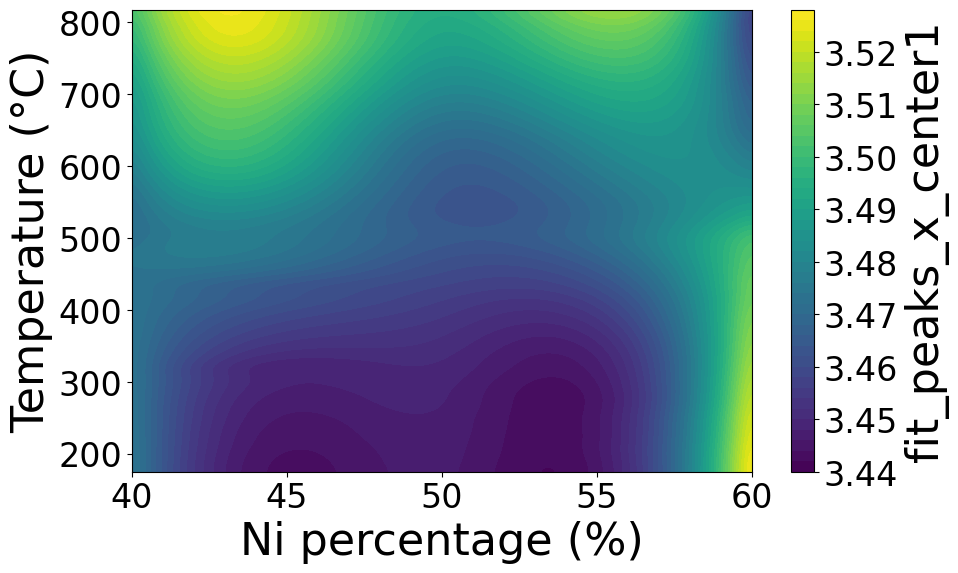

In [13]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import FormatStrFormatter

LABEL_FONTSIZE = 32
TICK_FONTSIZE = 24
TEXT_FONTSIZE = 20

x = np.arange(df_all.shape[1])  # sample index
x = np.linspace(40, 60, df_all.shape[1])
y = np.arange(df_all.shape[0])  # scan index
y = (35 - y*0.4) * 21.4154 + 67.64326
# y = y*0.4

step = (x[-1] - x[0]) / (len(x) - 1)  # spacing between samples (= 5)

# Finer grid for interpolation
# Extend xi to cover the half-cell margins
# xi = np.linspace(x.min() - step/2, x.max() + step/2, 200)
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

interp = RegularGridInterpolator((y, x), df_all.values, method='cubic',
bounds_error=False, fill_value=None) # 'linear', 'nearest', 'slinear', 'cubic', 'quintic'
Zi = interp((Yi, Xi))
Zi_smooth = gaussian_filter(Zi, sigma=3)  # adjust sigma for more/less smoothing

# plt.figure(figsize=(10, 6))
# plt.contourf(Xi, Yi, Zi, levels=50, cmap='viridis')
# plt.colorbar(label=FEATURE1)
# plt.xticks(x, [c.split("-")[1] for c in df_all.columns])
# plt.ylabel('Scan index')
# plt.xlabel('Sample')
# plt.show()


plt.figure(figsize=(10, 6))
plt.contourf(Xi, Yi, Zi_smooth, levels=50, cmap='viridis')
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.set_label(FEATURE1, fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=TICK_FONTSIZE)
# plt.xticks(x, [c.split("-")[1] for c in df_all.columns])
plt.xticks(x, fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
# plt.gca().invert_yaxis()
plt.ylabel('Temperature (°C)', fontsize=LABEL_FONTSIZE)
plt.xlabel('Ni percentage (%)', fontsize=LABEL_FONTSIZE)
plt.show()

## Discrete GT data - interp_per_sample

In [25]:
from scipy.interpolate import interp1d

x = np.arange(df_all.shape[1])  # sample index
x = np.linspace(40, 60, df_all.shape[1])
y = np.arange(df_all.shape[0])  # scan index
# y = (35 - y*0.4) * 21.4154 + 67.64326
y = y*0.4

# Fine y grid for the lookup table
y_fine = np.linspace(y.min(), y.max(), 1000)
df_all.columns = [40, 45, 50, 55, 60]
# Build interpolated lookup table: rows = fine y positions, cols = samples
lut = pd.DataFrame(index=y_fine, columns=df_all.columns, dtype=float)

for col in df_all.columns:
    f = interp1d(y, df_all[col].values, kind='cubic')
    lut[col] = f(y_fine)

interp_per_sample = {
    col: interp1d(y, df_all[col].values, kind='cubic')
    for col in df_all.columns
}

# Usage: get value for sample C02 at temperature 750
# composition = 45
# x_pos = 500
# value = interp_per_sample[composition](x_pos)
# value


## 2D gpCAM simulation - interpolated

In [7]:
N_INIT = 5
N_ITER = 100
ACQ_FUNCTION = 'variance'
METHOD = 'global'

# The latent function wraps your interpolated map
def latent_function(coords):
    """coords: shape (n, 2) where columns are [y_val, x_val]"""
    return interp(coords)

# Define bounds matching your data range
bounds = np.array([
    [y.min(), y.max()],  # dimension 0: y (e.g. position in mm)
    [x.min(), x.max()],  # dimension 1: x (sample index)
])

# Sample some initial training points
np.random.seed(42)
x_init = np.column_stack([
    np.random.uniform(bounds[0, 0], bounds[0, 1], N_INIT),
    np.random.uniform(bounds[1, 0], bounds[1, 1], N_INIT),
])
y_init = latent_function(x_init)

# Setup GP
my_gp = GPOptimizer(x_init, y_init)
my_gp.train()

# Run optimization loop
print(f"Iter number: x= [temperature, composition], predicted= target, true= true y value")
for i in range(N_ITER):
    result = my_gp.ask(bounds, acquisition_function=ACQ_FUNCTION, method=METHOD)
    new_x = result["x"]
    new_y = latent_function(new_x)
    if i % 10 == 0:
        print(f"Iter {i}: x={new_x}, predicted={result['f_a(x)']}, true={new_y}")
        my_gp.train()
    my_gp.tell(new_x, new_y)

# Compare: ground truth vs GP prediction on a grid
pred_points = np.column_stack([Yi.ravel(), Xi.ravel()])
mean = my_gp.posterior_mean(pred_points)["m(x)"].reshape(Yi.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].invert_yaxis()
axes[0].contourf(Xi, Yi, Zi_smooth, levels=50, cmap='viridis')
axes[0].set_title(f'Ground Truth')
axes[1].invert_yaxis()
axes[1].contourf(Xi, Yi, mean, levels=50, cmap='viridis')
axes[1].scatter(my_gp.x_data[:, 1], my_gp.x_data[:, 0], c='red', s=10, label='Sampled points')
axes[1].scatter(x_init[:, 1], x_init[:, 0], c='black', s=10, label='Trained points')
axes[1].set_title(f'GP Prediction - {N_INIT}/{N_ITER}/{ACQ_FUNCTION}/{METHOD}')
axes[1].legend()
plt.colorbar(axes[0].collections[0], ax=axes[0], label=FEATURE1)
plt.colorbar(axes[1].collections[0], ax=axes[1], label=FEATURE1)
plt.tight_layout()
plt.show()

# print([y[0], x[4]])
# res = latent_function([800, 2])
# res

NameError: name 'interp' is not defined

## 2D gpCAM simulation - discrete

Bounds: [[ 0. 30.]
 [40. 60.]]
Seed number: 42
X init: [[11.23620357 50.        ]
 [28.52142919 50.        ]
 [21.95981825 50.        ]
 [17.95975453 60.        ]
 [ 4.68055921 55.        ]]
Iter   0: x=[[ 0.75078607 40.        ]], predicted=0.01557, true=3.50184


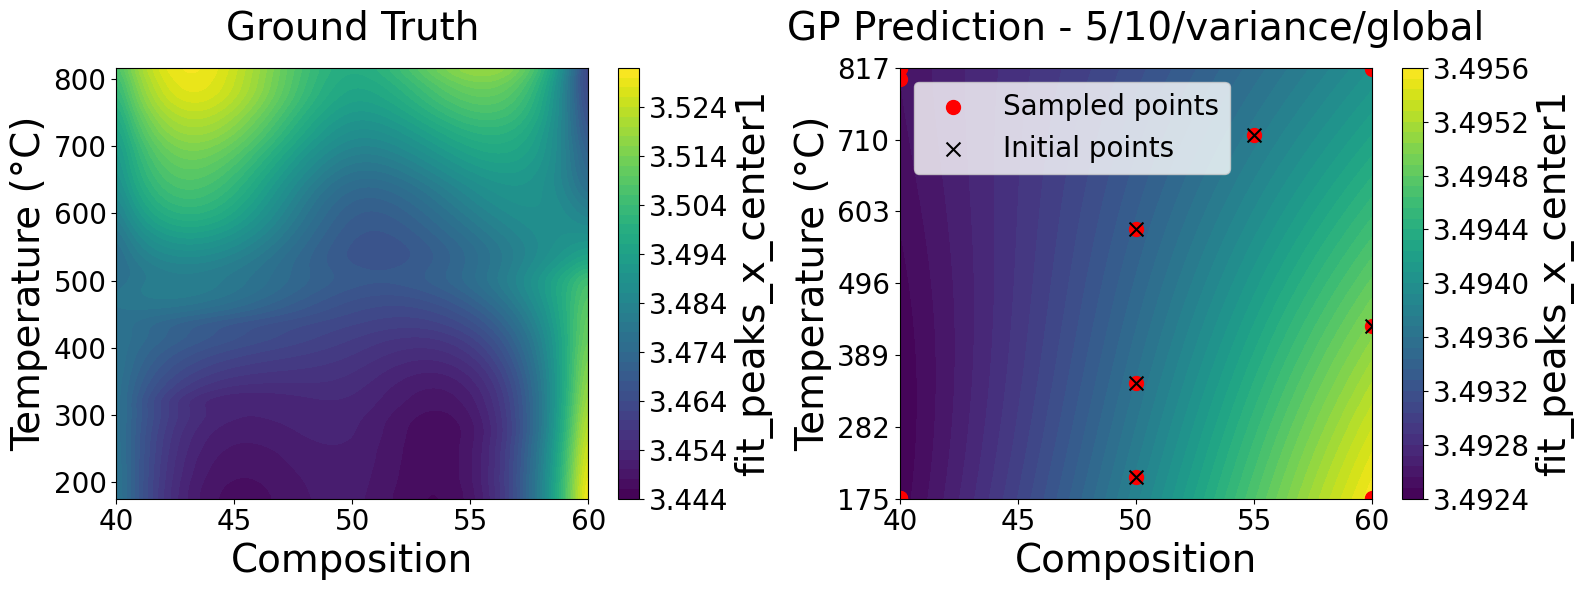

In [43]:
N_INIT = 5
N_ITER = 10
ACQ_FUNCTION = 'variance'
METHOD = 'global'
LABEL_FONTSIZE = 28
TICK_FONTSIZE = 20
TEXT_FONTSIZE = 20

# Discrete sample keys from interp_per_sample
_sample_keys = np.array(list(interp_per_sample.keys()), dtype=float)

def snap_x(x_vals_1d):
    """Snap continuous x values to nearest discrete sample key."""
    x_vals_1d = np.atleast_1d(x_vals_1d)
    idx = np.argmin(np.abs(x_vals_1d[:, None] - _sample_keys[None, :]), axis=1)
    return _sample_keys[idx]

def latent_function(coords):
    """coords: shape (n, 2) where columns are [y_val, x_val]"""
    coords = np.atleast_2d(coords)
    y_vals = coords[:, 0]
    x_vals = coords[:, 1]
    nearest_idx = np.argmin(np.abs(x_vals[:, None] - _sample_keys[None, :]), axis=1)
    results = np.zeros(len(coords))
    for i, key in enumerate(_sample_keys):
        mask = nearest_idx == i
        if mask.any():
            results[mask] = interp_per_sample[key](y_vals[mask])
    return results

# Bounds: y continuous, x spans composition key range
bounds = np.array([
    [y.min(), y.max()],
    [_sample_keys.min(), _sample_keys.max()],
])
print(f'Bounds: {bounds}')
# Initial points — draw x directly from discrete keys
np.random.seed(42)
state = np.random.get_state()
print(f'Seed number: {state[1][0]}')  # The seed is stored here
# print(f'Random samples: {np.random.rand(3)}')  # Compare this output across runs

x_init = np.column_stack([
    np.random.uniform(bounds[0, 0], bounds[0, 1], N_INIT),
    np.random.choice(_sample_keys, N_INIT),
])
print(f'X init: {x_init}')
y_init = latent_function(x_init)

# Setup GP
my_gp = GPOptimizer(x_init, y_init)
my_gp.train()

# Run optimization loop
for i in range(N_ITER):
    result = my_gp.ask(bounds, acquisition_function=ACQ_FUNCTION, method=METHOD)
    new_x = result["x"]

    # Snap x to nearest discrete sample before evaluation and telling
    new_x_snapped = new_x.copy()
    new_x_snapped[:, 1] = snap_x(new_x[:, 1])
    new_y = latent_function(new_x_snapped)
    my_gp.tell(new_x_snapped, new_y)  # tell GP the snapped x, not raw suggestion

    if i % 10 == 0:
        print(f"Iter {i:3d}: x={new_x_snapped}, predicted={result['f_a(x)'][0]:.5f}, true={new_y[0]:.5f}")
        my_gp.train()

# Prediction grid aligned to composition key range
xi_plot = np.linspace(_sample_keys.min(), _sample_keys.max(), 200)
yi_plot = np.linspace(y.min(), y.max(), 200)
Xi_plot, Yi_plot = np.meshgrid(xi_plot, yi_plot)
pred_points = np.column_stack([Yi_plot.ravel(), Xi_plot.ravel()])
mean = my_gp.posterior_mean(pred_points)["m(x)"].reshape(Yi_plot.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# axes[0].invert_yaxis()
axes[0].contourf(Xi, Yi, Zi_smooth, levels=50, cmap='viridis')
axes[0].set_title('Ground Truth', fontsize=LABEL_FONTSIZE, pad=TEXT_FONTSIZE)
axes[0].set_xlabel('Composition', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Temperature (°C)', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(labelsize=TICK_FONTSIZE)

axes[1].invert_yaxis()
axes[1].contourf(Xi_plot, Yi_plot, mean, levels=50, cmap='viridis')
axes[1].scatter(my_gp.x_data[:, 1], my_gp.x_data[:, 0], c='red', s=100, label='Sampled points')
axes[1].scatter(x_init[:, 1], x_init[:, 0], c='black', s=100, marker='x', label='Initial points')
axes[1].set_title(f'GP Prediction - {N_INIT}/{N_ITER}/{ACQ_FUNCTION}/{METHOD}', fontsize=LABEL_FONTSIZE, pad=TEXT_FONTSIZE)
axes[1].set_xlabel('Composition', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('Temperature (°C)', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(labelsize=TICK_FONTSIZE)
axes[1].legend(fontsize=TICK_FONTSIZE)
cbar0 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar0.set_label(FEATURE1, fontsize=LABEL_FONTSIZE)
cbar0.ax.tick_params(labelsize=TICK_FONTSIZE)

cbar1 = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar1.set_label(FEATURE1, fontsize=LABEL_FONTSIZE)
cbar1.ax.tick_params(labelsize=TICK_FONTSIZE)

from matplotlib.ticker import FuncFormatter

def to_temp(y, pos):
    return f'{(35 - y) * 21.4154 + 67.64326:.0f}'

temp_formatter = FuncFormatter(to_temp)

# for ax in axes:
#     ax.yaxis.set_major_formatter(temp_formatter)
#     ax.set_xlabel('Composition')
#     ax.set_ylabel('Temperature (°C)')  # update label too

axes[1].yaxis.set_major_formatter(temp_formatter)
axes[1].set_xlabel('Composition')
axes[1].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

## Acquisition functions - interpolated

Seed number: 42
Random samples: [0.37454012 0.95071431 0.73199394]
X init: [[17.95975453 52.02230023]
 [ 4.68055921 54.16145156]
 [ 4.67983561 40.41168989]
 [ 1.74250837 59.39819704]
 [25.98528437 56.64885282]]

--- ucb ---
Iter 0: x=[[29.97358116 40.0104798 ]], predicted=[3.56880202], true=[3.4803284]
Done — total points sampled: 15

--- expected improvement ---
Iter 0: x=[[29.96114237 40.00137266]], predicted=[0.00749867], true=[3.48033183]
Done — total points sampled: 15

--- variance ---
Iter 0: x=[[29.99833336 40.00573921]], predicted=[0.0213438], true=[3.48032058]
Done — total points sampled: 15


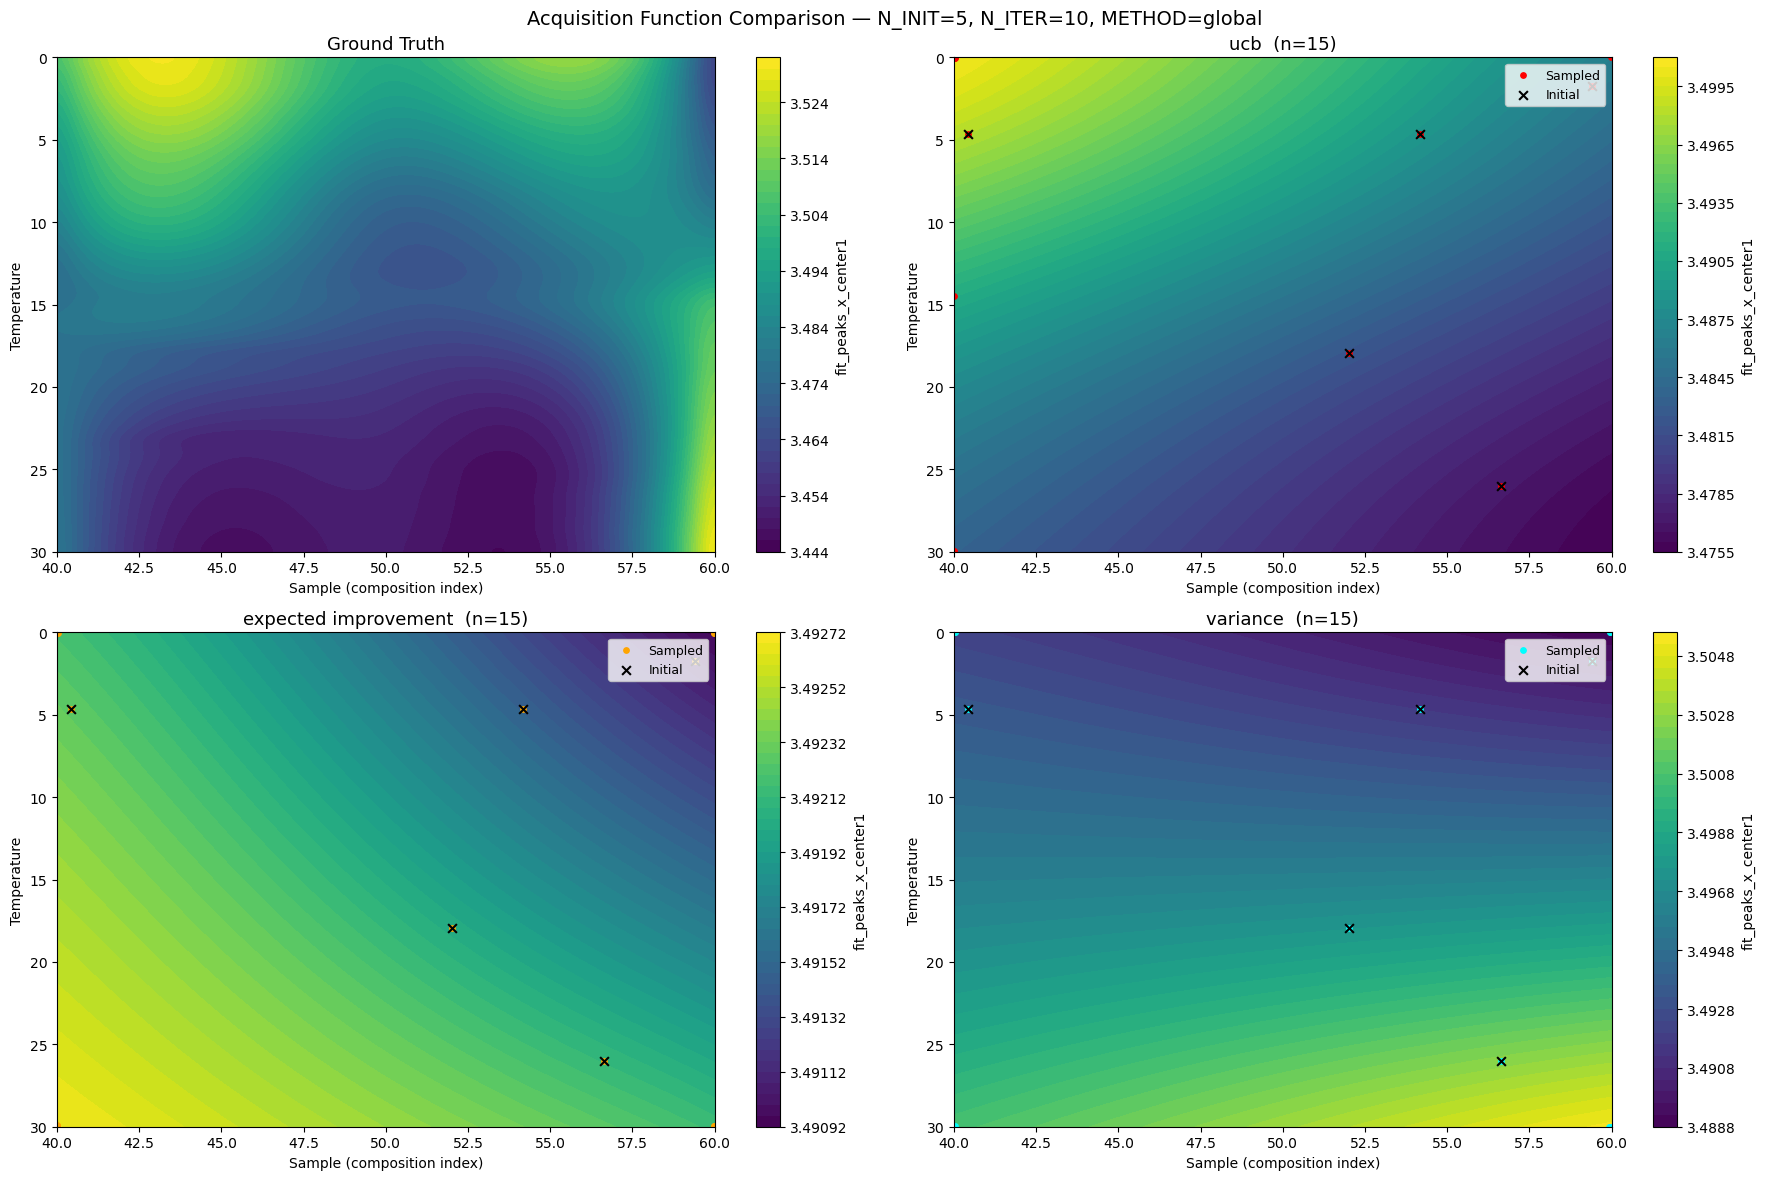

In [24]:

ACQ_FUNCTIONS_COMPARE = ['ucb', 'expected improvement', 'variance']
METHOD = 'global'
N_ITER = 10

# Same initial points as above (fixed seed)
np.random.seed(42)
state = np.random.get_state()
print(f'Seed number: {state[1][0]}')  # The seed is stored here
print(f'Random samples: {np.random.rand(3)}')  # Compare this output across runs
x_init_cmp = np.column_stack([
    np.random.uniform(bounds[0, 0], bounds[0, 1], N_INIT),
    np.random.uniform(bounds[1, 0], bounds[1, 1], N_INIT),
])
print(f'X init: {x_init_cmp}')
y_init_cmp = latent_function(x_init_cmp)


results = {}  # {acq_func: (gp, mean_grid)}

for acq in ACQ_FUNCTIONS_COMPARE:
    print(f"\n--- {acq} ---")
    gp = GPOptimizer(x_init_cmp, y_init_cmp)
    gp.train()
    for i in range(N_ITER):
        res = gp.ask(bounds, acquisition_function=acq, method=METHOD)
        gp.tell(res["x"], latent_function(res["x"]))
        if i % 10 == 0:
            gp.train()
            print(f"Iter {i}: x={res['x']}, predicted={res['f_a(x)']}, true={latent_function(res['x'])}")
    mean_grid = gp.posterior_mean(pred_points)["m(x)"].reshape(Yi.shape)
    results[acq] = (gp, mean_grid)
    print(f"Done — total points sampled: {len(gp.x_data)}")

# Shared color scale anchored to ground truth
vmin, vmax = Zi_smooth.min(), Zi_smooth.max()
sample_colors = {'ucb': 'red', 'expected improvement': 'orange', 'variance': 'cyan'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()


# --- Ground truth (top-left) ---
cf0 = axes[0].contourf(Xi, Yi, Zi_smooth, levels=50, cmap='viridis')    # , vmin=vmin, vmax=vmax
axes[0].set_title('Ground Truth', fontsize=13)
plt.colorbar(cf0, ax=axes[0], label=FEATURE1)
axes[0].invert_yaxis()

# --- One panel per acquisition function ---
for ax, acq in zip(axes[1:], ACQ_FUNCTIONS_COMPARE):
    gp, mean_grid = results[acq]
    cf = ax.contourf(Xi, Yi, mean_grid, levels=50, cmap='viridis')  # , vmin=vmin, vmax=vmax
    ax.scatter(gp.x_data[:, 1], gp.x_data[:, 0],
               c=sample_colors[acq], s=15, label='Sampled')
    ax.scatter(x_init_cmp[:, 1], x_init_cmp[:, 0],
               c='black', s=40, marker='x', label='Initial')
    ax.set_title(f'{acq}  (n={len(gp.x_data)})', fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.invert_yaxis()
    plt.colorbar(cf, ax=ax, label=FEATURE1)

for ax in axes:
    ax.set_xlabel('Sample (composition index)')
    ax.set_ylabel('Temperature')

plt.suptitle(
    f'Acquisition Function Comparison — N_INIT={N_INIT}, N_ITER={N_ITER}, METHOD={METHOD}',
    fontsize=14
)
plt.tight_layout()
plt.show()

## Acquisition functions - discrete

X init: [[11.23620357 50.        ]
 [28.52142919 50.        ]
 [21.95981825 50.        ]
 [17.95975453 60.        ]
 [ 4.68055921 55.        ]]

--- variance ---
  Iter   0: x=[[ 0.75078607 40.        ]], predicted=0.01557, true=3.50184
  Iter  10: x=[[3.22581537e-03 6.00000000e+01]], predicted=0.01170, true=3.45804
  Iter  20: x=[[9.39347881e-04 5.00000000e+01]], predicted=0.01374, true=3.49911
  Iter  30: x=[[29.99500529 45.        ]], predicted=0.01479, true=3.44707
  Iter  40: x=[[29.97672455 50.        ]], predicted=0.01485, true=3.45047
  Iter  50: x=[[1.67342319e-02 6.00000000e+01]], predicted=0.01733, true=3.45794
  Iter  60: x=[[5.0000889e-02 5.5000000e+01]], predicted=0.02482, true=3.51897
  Iter  70: x=[[1.57412998e-03 4.50000000e+01]], predicted=0.01216, true=3.52562
  Iter  80: x=[[16.65526436 60.        ]], predicted=0.00890, true=3.51156
  Iter  90: x=[[ 7.5096251 60.       ]], predicted=0.01479, true=3.47221
Done — total points sampled: 105

--- ucb ---
  Iter   0: x=[[

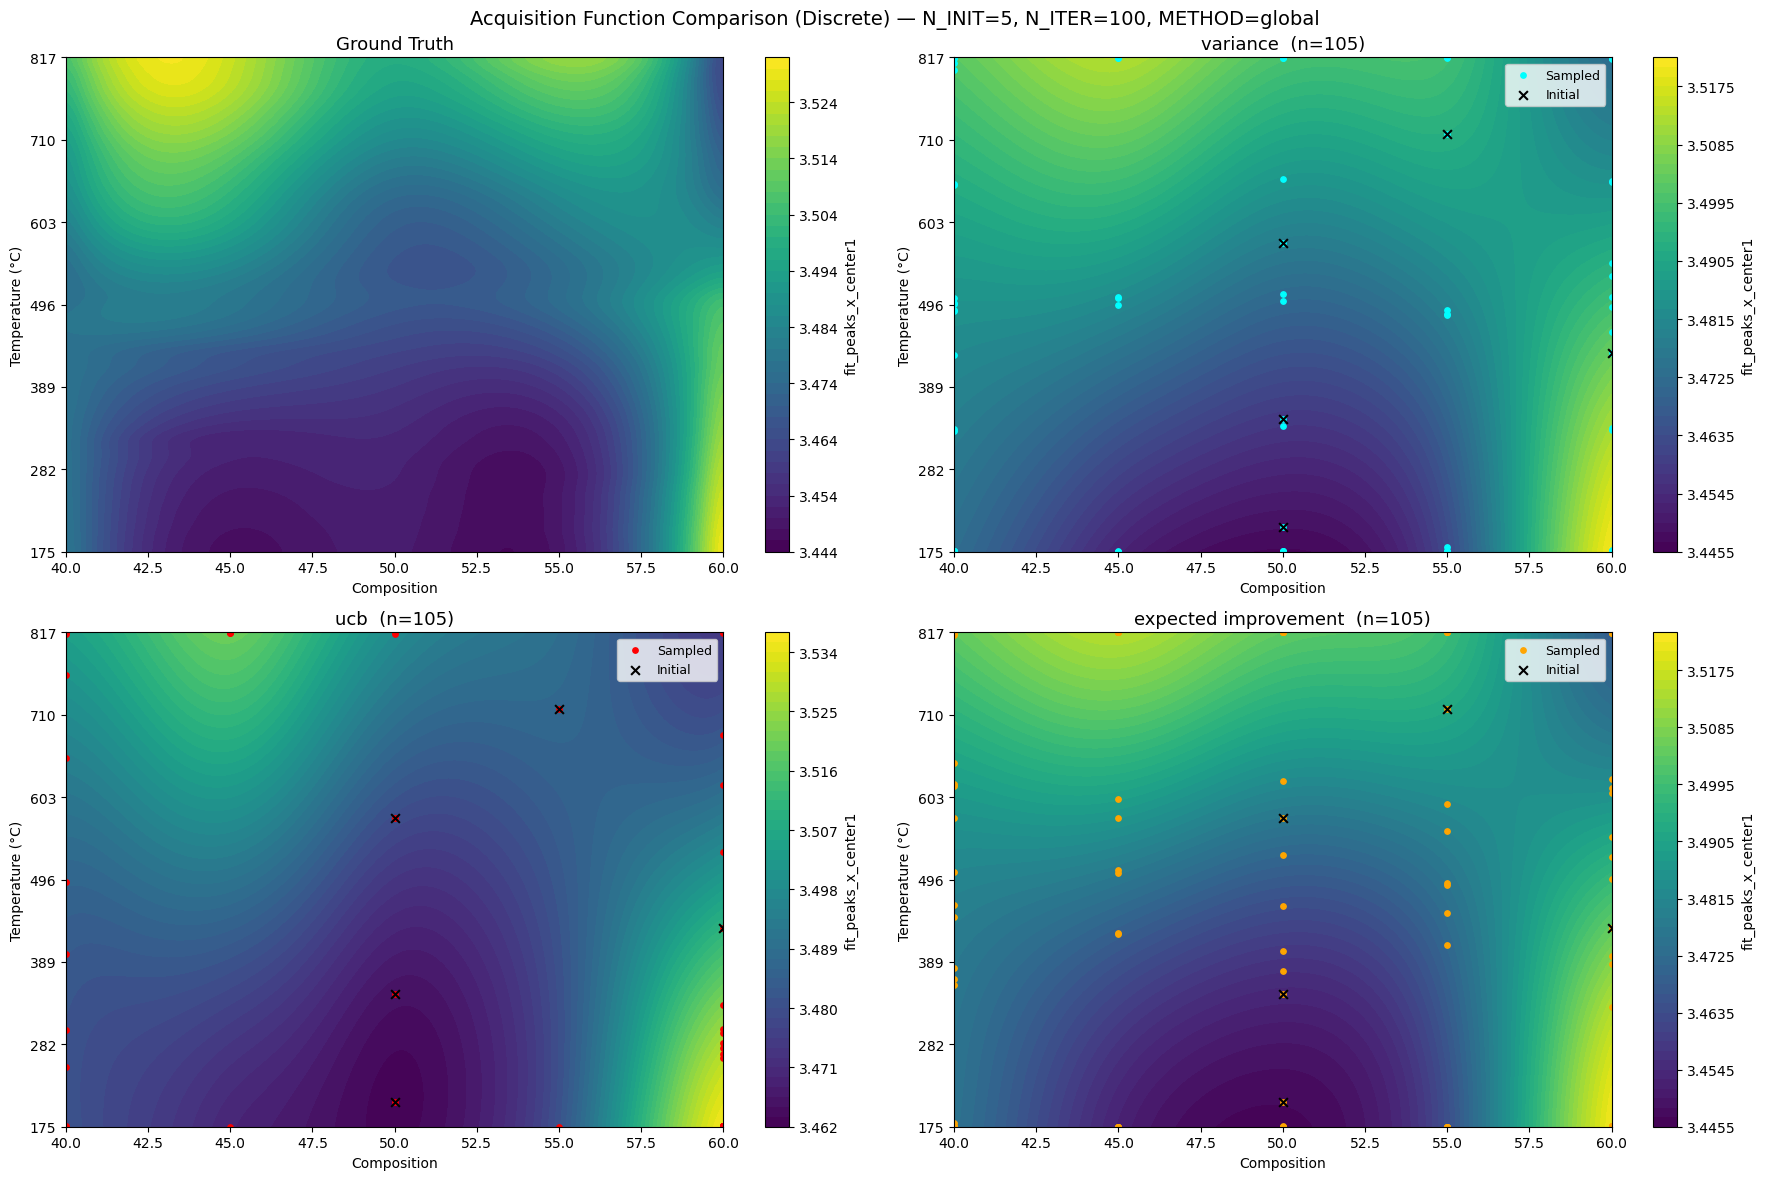

In [18]:
ACQ_FUNCTIONS_COMPARE = ['variance', 'ucb', 'expected improvement']
METHOD = 'global'
N_INIT = 5
N_ITER = 100

# Same initial points — discrete x sampling
np.random.seed(42)
x_init_cmp = np.column_stack([
    np.random.uniform(bounds[0, 0], bounds[0, 1], N_INIT),
    np.random.choice(_sample_keys, N_INIT),
])
print(f'X init: {x_init_cmp}')
y_init_cmp = latent_function(x_init_cmp)

# Prediction grid (shared)
xi_plot = np.linspace(_sample_keys.min(), _sample_keys.max(), 200)
yi_plot = np.linspace(y.min(), y.max(), 200)
Xi_plot, Yi_plot = np.meshgrid(xi_plot, yi_plot)
pred_points_cmp = np.column_stack([Yi_plot.ravel(), Xi_plot.ravel()])

results = {}  # {acq_func: (gp, mean_grid)}

for acq in ACQ_FUNCTIONS_COMPARE:
    print(f"\n--- {acq} ---")
    gp = GPOptimizer(x_init_cmp.copy(), y_init_cmp.copy())
    gp.train()
    for i in range(N_ITER):
        res = gp.ask(bounds, acquisition_function=acq, method=METHOD)
        new_x = res["x"]
        new_x_snapped = new_x.copy()
        new_x_snapped[:, 1] = snap_x(new_x[:, 1])
        new_y = latent_function(new_x_snapped)
        gp.tell(new_x_snapped, new_y)
        if i % 10 == 0:
            gp.train()
            print(f"  Iter {i:3d}: x={new_x_snapped}, predicted={res['f_a(x)'][0]:.5f}, true={new_y[0]:.5f}")
    mean_grid = gp.posterior_mean(pred_points_cmp)["m(x)"].reshape(Yi_plot.shape)
    results[acq] = (gp, mean_grid)
    print(f"Done — total points sampled: {len(gp.x_data)}")

# Shared color scale
vmin, vmax = Zi_smooth.min(), Zi_smooth.max()
sample_colors = {'ucb': 'red', 'expected improvement': 'orange', 'variance': 'cyan'}

from matplotlib.ticker import FuncFormatter
def to_temp(val, pos):
    return f'{(35 - val) * 21.4154 + 67.64326:.0f}'
temp_formatter = FuncFormatter(to_temp)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Ground truth (top-left)
cf0 = axes[0].contourf(Xi, Yi, Zi_smooth, levels=50, cmap='viridis')
axes[0].set_title('Ground Truth', fontsize=13)
axes[0].invert_yaxis()
plt.colorbar(cf0, ax=axes[0], label=FEATURE1)

# One panel per acquisition function
for ax, acq in zip(axes[1:], ACQ_FUNCTIONS_COMPARE):
    gp, mean_grid = results[acq]
    cf = ax.contourf(Xi_plot, Yi_plot, mean_grid, levels=50, cmap='viridis')
    ax.scatter(gp.x_data[:, 1], gp.x_data[:, 0],
               c=sample_colors[acq], s=15, label='Sampled')
    ax.scatter(x_init_cmp[:, 1], x_init_cmp[:, 0],
               c='black', s=40, marker='x', label='Initial')
    ax.set_title(f'{acq}  (n={len(gp.x_data)})', fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.invert_yaxis()
    plt.colorbar(cf, ax=ax, label=FEATURE1)

for ax in axes:
    ax.yaxis.set_major_formatter(temp_formatter)
    ax.set_xlabel('Composition')
    ax.set_ylabel('Temperature (°C)')

plt.suptitle(
    f'Acquisition Function Comparison (Discrete) — N_INIT={N_INIT}, N_ITER={N_ITER}, METHOD={METHOD}',
    fontsize=14
)
plt.tight_layout()
plt.show()


# End